In [127]:
import pandas as pd

df = pd.read_csv(
    "../data/student-mat.csv",
    sep=";"
)

print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [128]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (395, 33)

Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 n

In [129]:
print(df["G3"].describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


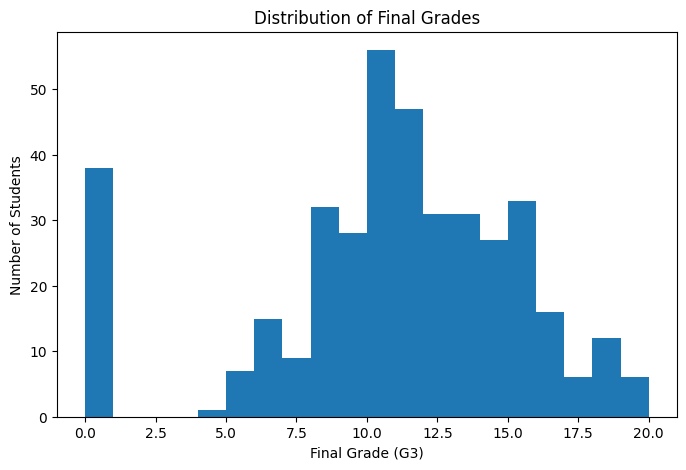

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=20)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

In [131]:
corr = df.corr(numeric_only=True)

print(
    corr["G3"]
    .sort_values(ascending=False)
)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


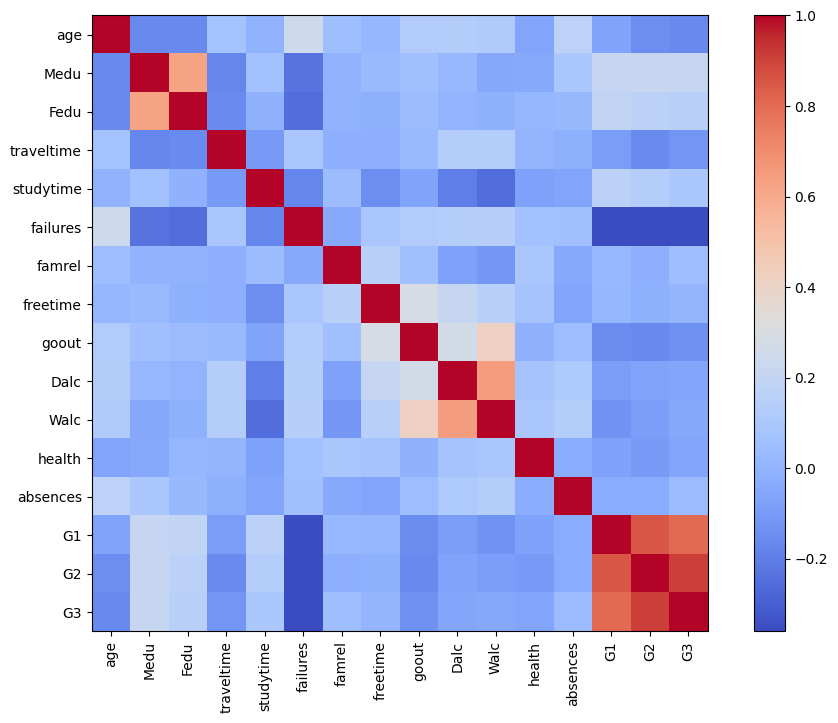

In [132]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

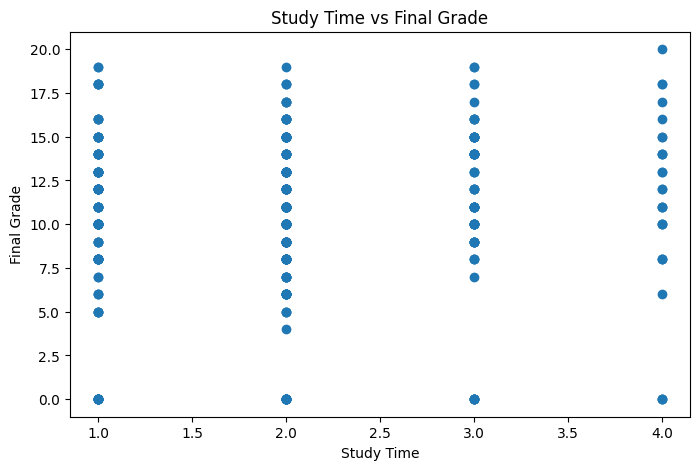

In [133]:
plt.figure(figsize=(8,5))
plt.scatter(df["studytime"], df["G3"])
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Grade")
plt.show()

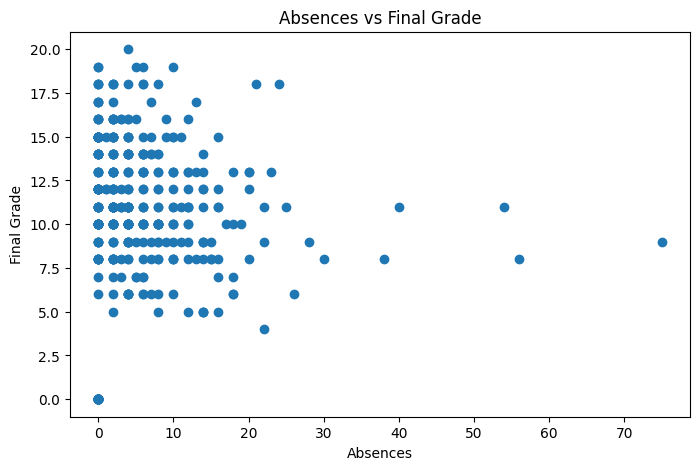

In [134]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")
plt.show()

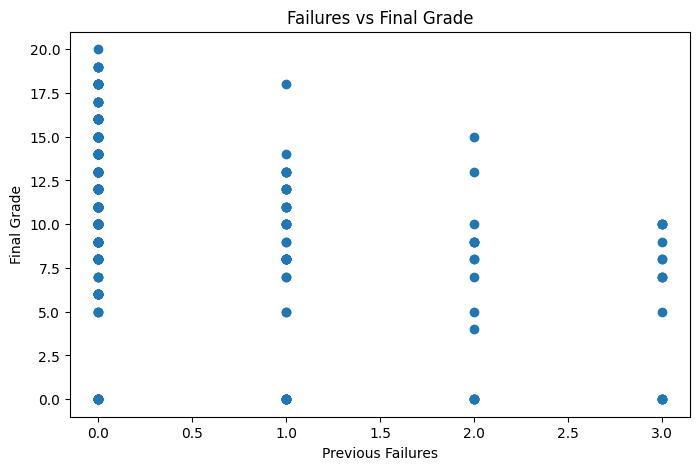

In [135]:
plt.figure(figsize=(8,5))
plt.scatter(df["failures"], df["G3"])
plt.xlabel("Previous Failures")
plt.ylabel("Final Grade")
plt.title("Failures vs Final Grade")
plt.show()

In [136]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == "object":
        df_encoded[column] = encoder.fit_transform(df_encoded[column])

print(df_encoded.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [137]:
print(df_encoded.dtypes)

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


In [138]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == "object":
        df_encoded[column] = encoder.fit_transform(df_encoded[column])

print(df_encoded.head())

print(df_encoded.dtypes)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
school          str
sex             str
age           int64
address         str
famsize 

In [139]:
print(df_encoded.select_dtypes(include=['object']).columns)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_15436\2231493801.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_encoded.select_dtypes(include=['object']).columns)


In [140]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=['str']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(df_encoded.dtypes)

school        int64
sex           int64
age           int64
address       int64
famsize       int64
Pstatus       int64
Medu          int64
Fedu          int64
Mjob          int64
Fjob          int64
reason        int64
guardian      int64
traveltime    int64
studytime     int64
failures      int64
schoolsup     int64
famsup        int64
paid          int64
activities    int64
nursery       int64
higher        int64
internet      int64
romantic      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


In [141]:
print(df_encoded.select_dtypes(include=['str']).columns)

Index([], dtype='str')


In [142]:
X = df_encoded.drop("G3", axis=1)
y = df_encoded["G3"]

In [143]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [144]:
print(X_train.select_dtypes(include=['str']).columns)

Index([], dtype='str')


In [145]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [146]:
import sklearn
print(sklearn.__version__)

1.8.0


Step 1: Train the Models

Linear Regression

In [147]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Random Forest

In [148]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Gradient Boosting

In [149]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

Step 2: Evaluate the Models

Import metrics:

In [150]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Linear Regression Metrics

In [151]:
print("=== Linear Regression ===")

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 :", r2_score(y_test, lr_pred))

=== Linear Regression ===
MAE: 1.4954750100522758
MSE: 5.03239410886674
R2 : 0.7545777855043501


Random Forest Metrics

In [152]:
print("=== Random Forest ===")

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 :", r2_score(y_test, rf_pred))

=== Random Forest ===
MAE: 1.1050632911392408
MSE: 3.4867417721518983
R2 : 0.8299569015097052


Gradient Boosting Metrics

In [153]:
print("=== Gradient Boosting ===")

print("MAE:", mean_absolute_error(y_test, gb_pred))
print("MSE:", mean_squared_error(y_test, gb_pred))
print("R2 :", r2_score(y_test, gb_pred))

=== Gradient Boosting ===
MAE: 1.0983963307912785
MSE: 3.3645211296206923
R2 : 0.8359174165445352


Step 3: Compare Models

Create a quick comparison:

In [154]:
results = {
    "Linear Regression": r2_score(y_test, lr_pred),
    "Random Forest": r2_score(y_test, rf_pred),
    "Gradient Boosting": r2_score(y_test, gb_pred)
}

print(results)

{'Linear Regression': 0.7545777855043501, 'Random Forest': 0.8299569015097052, 'Gradient Boosting': 0.8359174165445352}


Step 5: Feature Importance (Using Gradient Boosting)

In [155]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

       Feature  Importance
31          G2    0.782386
29    absences    0.137956
30          G1    0.016785
2          age    0.013813
22    romantic    0.005391
23      famrel    0.004882
10      reason    0.004614
11    guardian    0.004390
28      health    0.003467
25       goout    0.003157
8         Mjob    0.003117
13   studytime    0.002992
15   schoolsup    0.002505
7         Fedu    0.002081
18  activities    0.002081


Visualize Feature Importance

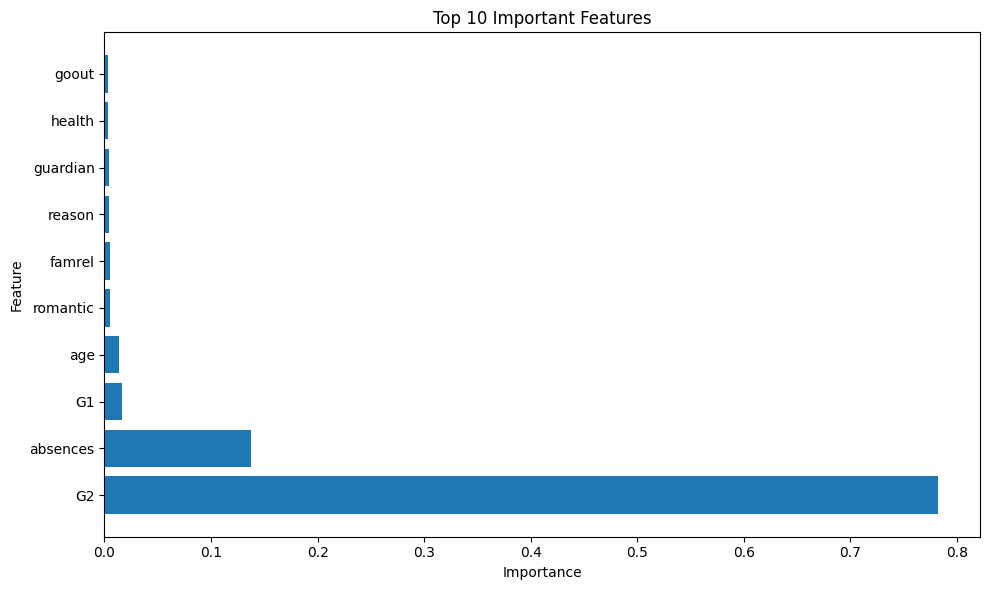

In [156]:
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.tight_layout()
plt.show()

Step 6: Actual vs Predicted Plot
This helps visualize model performance.

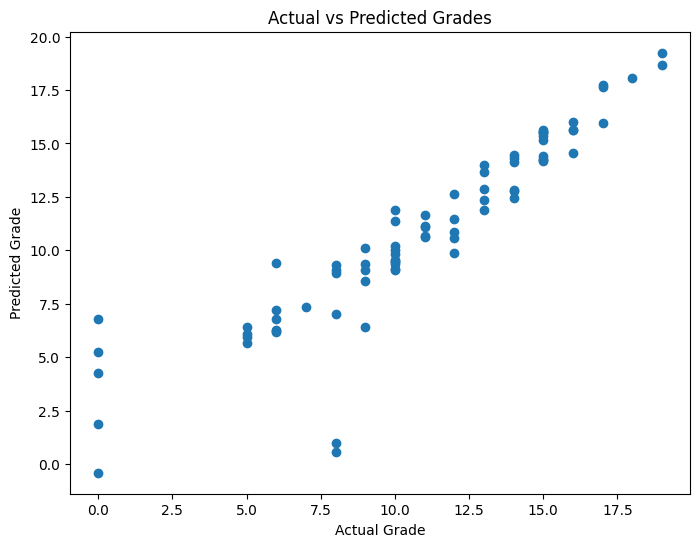

In [157]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, gb_pred)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Grades")

plt.show()

Step 7: Residual Analysis
Residuals show prediction errors.

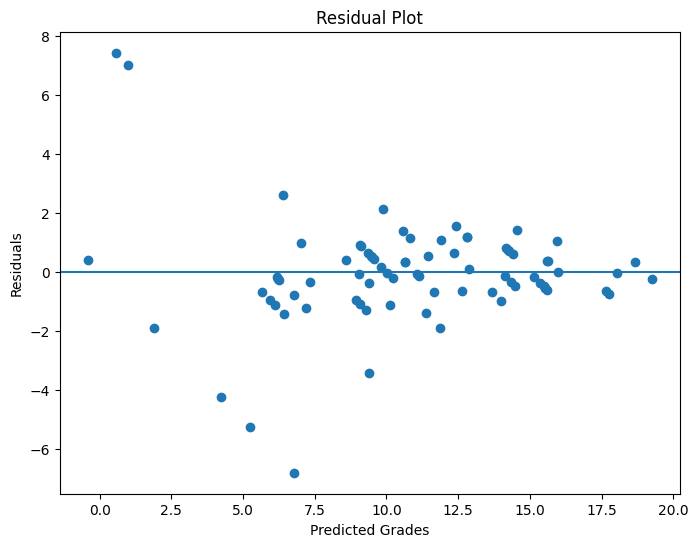

In [158]:
residuals = y_test - gb_pred

plt.figure(figsize=(8,6))

plt.scatter(gb_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Grades")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Step 8: Save the Model

In [159]:
import os

os.makedirs("model", exist_ok=True)

print("Folder created")

Folder created


In [160]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(gb, "model/student_performance_model.pkl")
joblib.dump(X.columns.tolist(), "model/feature_names.pkl")

print("Model saved successfully")

Model saved successfully


Step 9: Save Feature Names

In [161]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "model/feature_names.pkl"
)

print("Feature names saved")

Feature names saved


Step 10: Verify Saved Files

In [162]:
import os

print(os.listdir("model"))

['feature_names.pkl', 'student_performance_model.pkl']
